In [1]:
print("hello")

hello


In [2]:
import numpy as np
import mne

In [3]:
sample_data_file_path = r"C:\Users\neyma\eeg-pipeline\data\raw\physionet.org\files\chbmit\1.0.0\chb01"
sample_data_raw_file = f"{sample_data_file_path}/chb01_03.edf"
raw = mne.io.read_raw_edf(sample_data_raw_file)

Extracting EDF parameters from C:\Users\neyma\eeg-pipeline\data\raw\physionet.org\files\chbmit\1.0.0\chb01\chb01_03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\neyma\AppData\Local\Temp\ipykernel_40416\244210071.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(sample_data_raw_file)


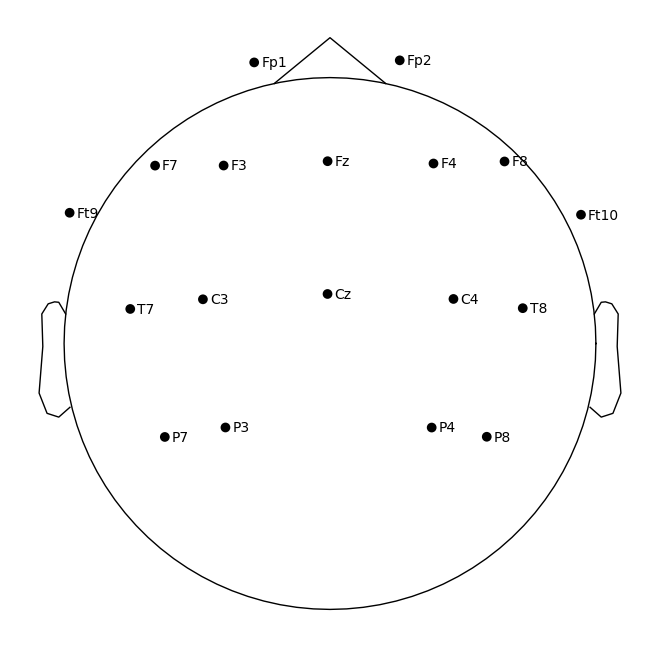

In [4]:
import re
replace_dict = {}
drop_list = []
# this loop is just a simple loop that i asked gpt to extract the first electrode from each channel.
for channel_name in raw.info['ch_names']:
    # get the name to change too
    name_change = re.findall('\w+',channel_name)[0].title()
    # check if it is already in the change list
    if name_change in list(replace_dict.values()):
        drop_list.append(channel_name)
    else:
        # if its not already there get the origional name and what we want to 
        # change it to
        replace_dict[channel_name] = name_change

raw.drop_channels(drop_list)
raw.rename_channels(replace_dict)
montage =  mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False)
_ = raw.plot_sensors(kind='select', show_names=True)

In [5]:
# reload raw
raw = mne.io.read_raw_edf(sample_data_raw_file)
print(raw.info)
print(raw.ch_names)
# the channel names are electrode minus electrode, this is preferred because it records the difference between pairs of adjacent electrodes
# Clinicians prefer this because it cancels out noise that affects both electrodes equally (like muscle movement or electrical interference), leaving only the brain signal between those two points.

Extracting EDF parameters from C:\Users\neyma\eeg-pipeline\data\raw\physionet.org\files\chbmit\1.0.0\chb01\chb01_03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
<Info | 7 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


C:\Users\neyma\AppData\Local\Temp\ipykernel_40416\1478918919.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(sample_data_raw_file)


In [6]:
print("channels:",raw.ch_names)
print("sampling rate:", raw.info['sfreq'], "Hz")
data, times = raw.get_data(return_times=True)
print("data shape:", data.shape)
print("times shape:", times.shape)

channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
sampling rate: 256.0 Hz
data shape: (23, 921600)
times shape: (921600,)


In [7]:
# sample values
print("Sample values (first channel, first 5):", data[0, :5])

Sample values (first channel, first 5): [-1.77777778e-05  1.95360195e-07  1.95360195e-07  5.86080586e-07
  1.95360195e-07]


In [8]:
print(raw)
print(raw.info)

<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~22 kB, data not loaded>
<Info | 7 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
>


Using matplotlib as 2D backend.


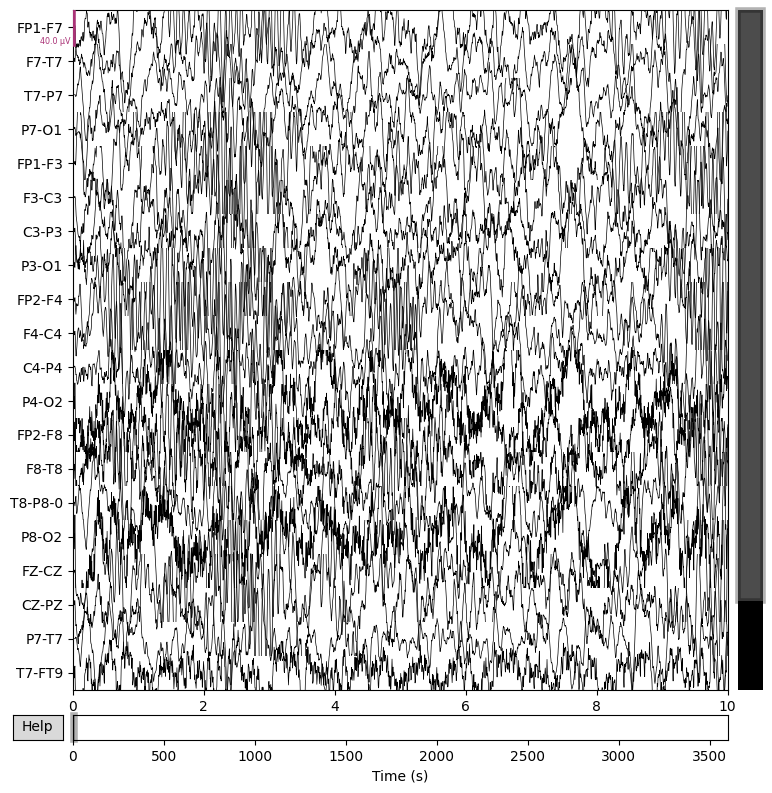

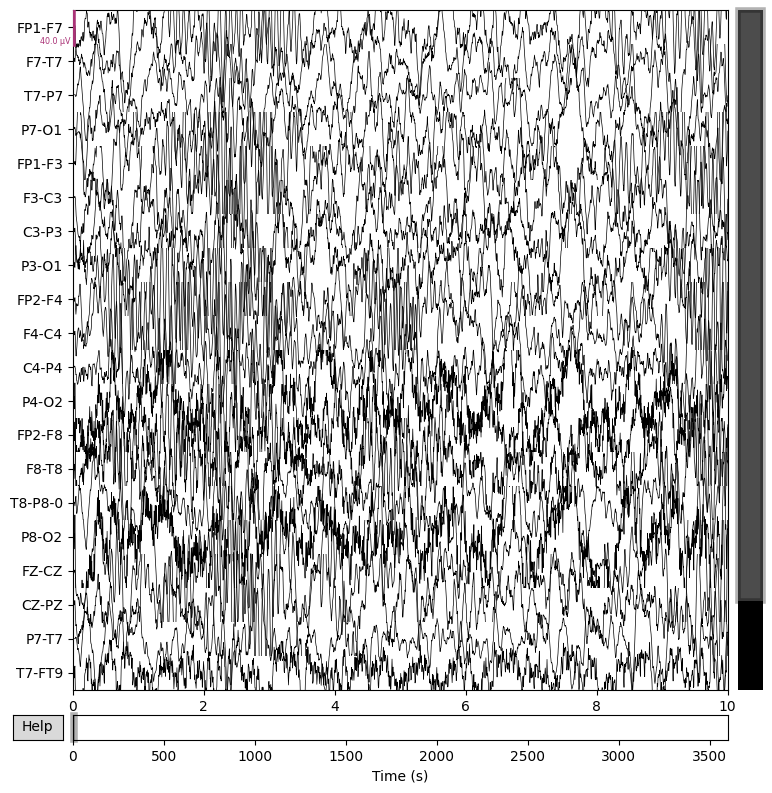

In [9]:
raw.plot()
# this generates the plot of raw EEG signals over time for each channel

Effective window size : 8.000 (s)


C:\Users\neyma\AppData\Local\Temp\ipykernel_40416\2697384441.py:1: RuntimeWarning: in version 1.5, the default behavior of Spectrum.plot() will change so that bad channels will be shown by default. To keep the old default behavior (and silence this warning), explicitly pass `picks='data', exclude='bads'`.
  raw.compute_psd().plot()
C:\Users\neyma\AppData\Local\Temp\ipykernel_40416\2697384441.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot()
c:\Users\neyma\eeg-pipeline\venv\Lib\site-packages\mne\viz\utils.py:151: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


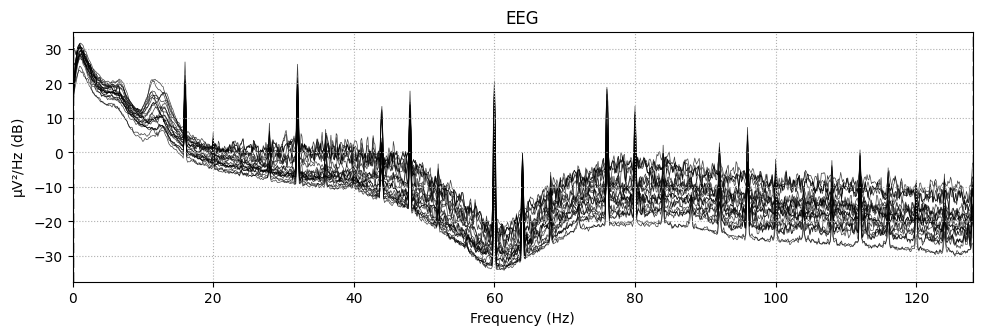

In [10]:
raw.compute_psd().plot()
# this plots the power spectral density (PSD) against frequency of EEG signals, 
# which is useful for analyzing the frequency content of the signals and identifying patterns or abnormalities in the brain activity.

In [ ]:
import pandas as pd
def parse_summary_txt(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data = []
    current_block = None
    for line in lines:
        if line.startswith('File Name'):
            filename = line.split(':',1)[1].strip()
            data.append({'FileName': filename})

    return pd.DataFrame(data)